<a href="https://colab.research.google.com/github/Hanaa879/Student-Performance-Analytics-System/blob/main/Student_Performance_Analytics_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
#@title  Student Performance Analytics System & Dashboard { run: "auto" }

# We have imported these python libraries to help us analyse the data, train the model and produce a good output
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder



In [8]:
#we will be connecting google drive to the Colab using code below
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
data = pd.read_csv('/content/drive/MyDrive/archive (2)/StudentsPerformance.csv')


In [10]:
# Display the first 5 rows to understand the structure
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [11]:
#So since all the ml models are in one cell we are giving a general cell to pre process the data but inside each ml model we need to go into specifics only in those sections
# Create Targets for both Classification and Regression
data['Average_Score'] = data[['math score', 'reading score', 'writing score']].mean(axis=1)
data['Performance'] = np.where(data['Average_Score'] >= 60, 1, 0)

# Target for Linear Regression (Continuous numeric marks)
y_reg = data['Average_Score']

# Target for Logistic Regression, KNN, Decision Tree, Random Forest (Binary Pass/Fail)
y = data['Performance']

# Separate features and convert text categories properly using One-Hot Encoding
# This avoids treating categorical data as arbitrary sequential numbers
X_raw = data.drop(['math score', 'reading score', 'writing score', 'Average_Score', 'Performance'], axis=1)
X = pd.get_dummies(X_raw, drop_first=True)

# 3. Scale features for distance-based models (KNN, K-Means, PCA)
# This prevents columns with wider ranges from dominating the algorithms
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Preview the ready-to-use features
print("--- Prepared Features Preview (X.head()) ---")
print(X.head())
print("-" * 44)

--- Prepared Features Preview (X.head()) ---
   gender_male  race/ethnicity_group B  race/ethnicity_group C  \
0        False                    True                   False   
1        False                   False                    True   
2        False                    True                   False   
3         True                   False                   False   
4         True                   False                    True   

   race/ethnicity_group D  race/ethnicity_group E  \
0                   False                   False   
1                   False                   False   
2                   False                   False   
3                   False                   False   
4                   False                   False   

   parental level of education_bachelor's degree  \
0                                           True   
1                                          False   
2                                          False   
3                              

Decision Tree → Academic performance analysis  
Training samples: 800
Testing samples: 200
Model trained successfully!
Accuracy Score: 0.67

Classification Report:
               precision    recall  f1-score   support

        Fail       0.46      0.35      0.40        62
        Pass       0.74      0.81      0.77       138

    accuracy                           0.67       200
   macro avg       0.60      0.58      0.59       200
weighted avg       0.65      0.67      0.66       200



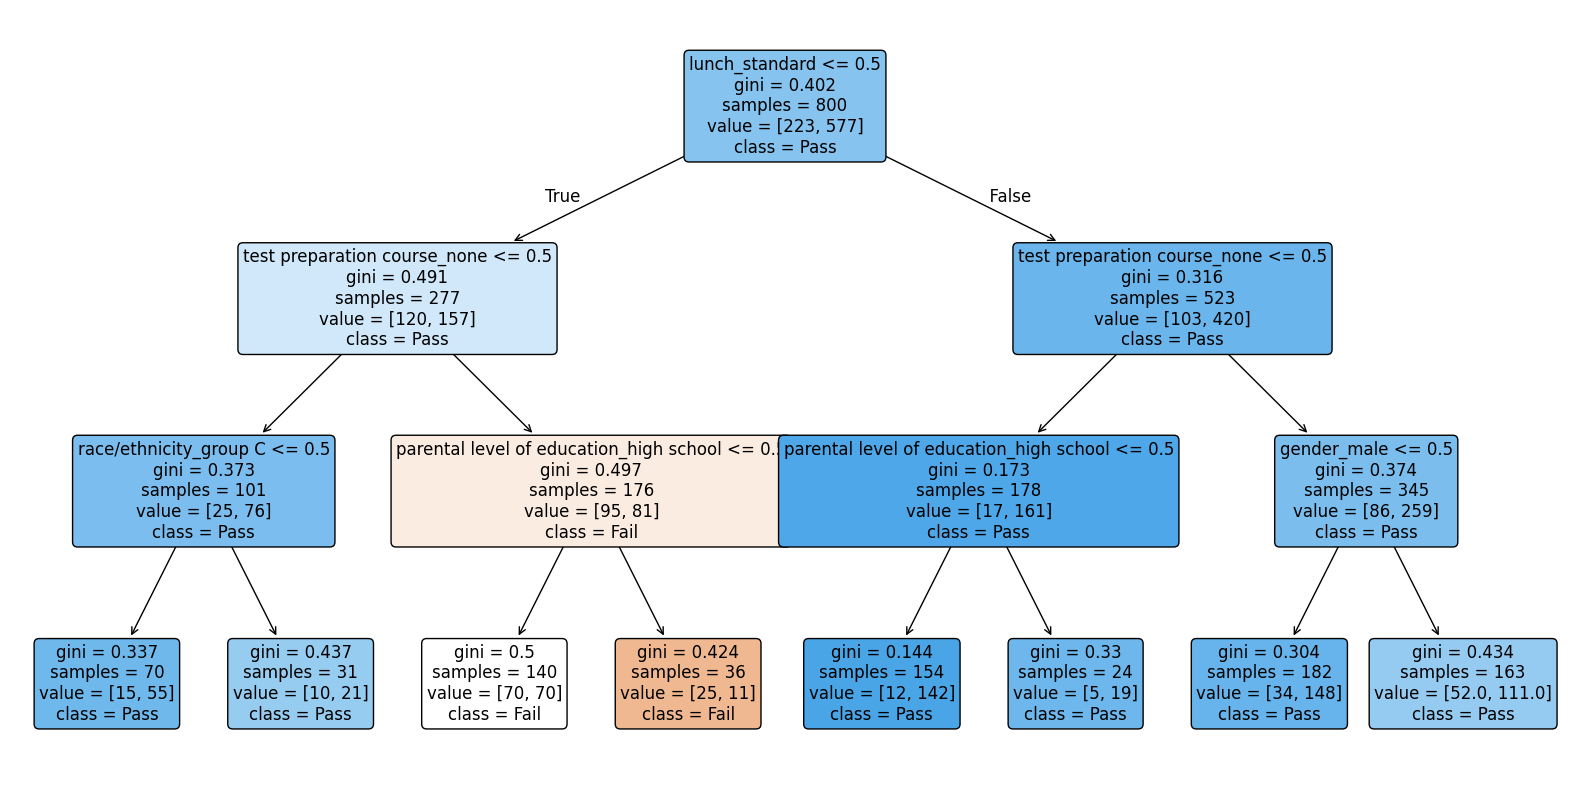


Key factors influencing academic performance:
                                          Feature  Importance
10                                 lunch_standard    0.468946
11                   test preparation course_none    0.383042
0                                     gender_male    0.069718
6         parental level of education_high school    0.066606
2                          race/ethnicity_group C    0.011689
1                          race/ethnicity_group B    0.000000
3                          race/ethnicity_group D    0.000000
4                          race/ethnicity_group E    0.000000
7     parental level of education_master's degree    0.000000
5   parental level of education_bachelor's degree    0.000000
9    parental level of education_some high school    0.000000
8        parental level of education_some college    0.000000


In [13]:
#@markdown Select a model from the dropdown menu to update the dashboard view.
# 2. The code below helps us select a dashboard to display in google collabs without having to download
Select_Model = "Decision Tree" #@param ["Linear Regression", "Logistic Regression", "KNN", "Decision Tree", "Random Forest", "K-Means", "PCA"]

# 3. DASHBOARD code
if Select_Model == "Decision Tree":
    print("Decision Tree → Academic performance analysis  ")

    # 1. Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    print(f"Training samples: {X_train.shape[0]}")
    print(f"Testing samples: {X_test.shape[0]}")

    # 2. Train Decision Tree
    model = DecisionTreeClassifier(max_depth=3, random_state=42)
    model.fit(X_train, y_train)
    print("Model trained successfully!")

    # 3. Evaluate and predict
    y_pred = model.predict(X_test)
    print("Accuracy Score:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=['Fail', 'Pass']))

    # 4. Plot tree visual
    plt.figure(figsize=(20, 10))
    plot_tree(model, feature_names=X.columns, class_names=['Fail', 'Pass'], filled=True, rounded=True, fontsize=12)
    plt.show()

    # 5. Extract Feature Importance (This belongs ONLY to Decision Tree)
    importances = model.feature_importances_
    feature_imp_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances}).sort_values(by='Importance', ascending=False)
    print("\nKey factors influencing academic performance:")
    print(feature_imp_df)

elif Select_Model == "Linear Regression":
    print("  Linear Regression → Marks prediction  ")
    # Your Linear Regression code goes here

elif Select_Model == "Logistic Regression":
    print(" Logistic Regression → Pass/Fail prediction  ")
    # Your Logistic Regression code goes here

elif Select_Model == "KNN":
    print(" KNN → Similar Student Retrieval Dashboard")

    from sklearn.compose import ColumnTransformer
    from sklearn.preprocessing import StandardScaler, OneHotEncoder
    from sklearn.neighbors import NearestNeighbors
    import matplotlib.pyplot as plt

    # 1. Prepare features
    X_knn_raw = data.copy()
    categorical_cols = ['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course']
    numerical_cols = ['math score', 'reading score', 'writing score']

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_cols),
            ('cat', OneHotEncoder(), categorical_cols)
        ])
    X_processed = preprocessor.fit_transform(X_knn_raw)

    # 2. Train KNN
    knn = NearestNeighbors(n_neighbors=6, metric='euclidean')
    knn.fit(X_processed)

    # 3. Define Retrieval Function with Dashboard Visuals
    def find_similar_students_dashboard(student_id, dataset, processed_data, model):
        target_student = processed_data[student_id].reshape(1, -1)
        distances, indices = model.kneighbors(target_student)

        # Extract target information
        target_info = dataset.iloc[student_id]

        # Split indices and distances to exclude the target student themselves
        similar_indices = indices[0][1:]
        similar_distances = distances[0][1:]

        # Build results dataframe
        results = dataset.iloc[similar_indices].copy()
        results.insert(0, 'Similarity Distance', similar_distances)

        # --- VISUAL COMPONENT 1: Header Dashboard Panel ---
        from IPython.display import display, HTML
        panel_html = f"""
        <div style="background-color: #1e1e24; padding: 15px; border-radius: 8px; border-left: 5px solid #4a90e2; color: white; margin-bottom: 20px;">
            <h3 style="margin-top: 0; color: #4a90e2;">🎯 Target Profile (Student ID: {student_id})</h3>
            <p><b>Demographics:</b> {target_info['gender'].title()} | {target_info['race/ethnicity']} | {target_info['parental level of education']}</p>
            <p><b>Scores:</b> Math: <span style="color: #ff6b6b;">{target_info['math score']}</span> | Reading: <span style="color: #4ecdc4;">{target_info['reading score']}</span> | Writing: <span style="color: #ffe66d;">{target_info['writing score']}</span></p>
        </div>
        """
        display(HTML(panel_html))

        # --- VISUAL COMPONENT 2: Comparison Charts ---
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

        # Chart A: Similarity Distances (Shorter = Closer)
        y_labels = [f"Student {idx}" for idx in results.index]
        bars = ax1.barh(y_labels, results['Similarity Distance'], color='#4a90e2', alpha=0.8)
        ax1.invert_yaxis()
        ax1.set_xlabel('Distance Metric (Lower means closer peer match)')
        ax1.set_title('Match Closeness Profile', fontsize=12, fontweight='bold')
        ax1.grid(axis='x', linestyle='--', alpha=0.4)

        # Add labels to the bars
        for bar in bars:
            width = bar.get_width()
            ax1.text(width + 0.05, bar.get_y() + bar.get_height()/2, f'{width:.2f}',
                     va='center', ha='left', fontsize=9, color='gray')

        # Chart B: Academic Benchmark Comparison
        categories = ['Math', 'Reading', 'Writing']
        target_scores = [target_info['math score'], target_info['reading score'], target_info['writing score']]
        peer_avg_scores = [results['math score'].mean(), results['reading score'].mean(), results['writing score'].mean()]

        x_indexes = np.arange(len(categories))
        width = 0.35

        ax2.bar(x_indexes - width/2, target_scores, width=width, label=f'Target (ID {student_id})', color='#ff6b6b')
        ax2.bar(x_indexes + width/2, peer_avg_scores, width=width, label='Top 5 Peers Avg', color='#4ecdc4')

        ax2.set_xticks(x_indexes)
        ax2.set_xticklabels(categories)
        ax2.set_ylabel('Scores')
        ax2.set_title('Academic Score Comparison', fontsize=12, fontweight='bold')
        ax2.legend()
        ax2.grid(axis='y', linestyle='--', alpha=0.4)

        plt.tight_layout()
        plt.show()

        # --- VISUAL COMPONENT 3: Peer Data Sheet ---
        print("\n Detailed Similar Peer Matrix:")
        return results

    # 4. Execute Interactive Output
    sim_results = find_similar_students_dashboard(student_id=42, dataset=data, processed_data=X_processed, model=knn)
    display(sim_results)
elif Select_Model == "Random Forest":
    print(" Random Forest → Dropout prediction risk ")
    # Your Random Forest code goes here

elif Select_Model == "K-Means":
    print(" K-Means → Student grouping cluster  ")
    from sklearn.cluster import KMeans

    # K-Means strictly groups the scaled data into distinct clusters
    kmeans_model = KMeans(n_clusters=3, random_state=42)
    clusters = kmeans_model.fit_predict(X_scaled)

    print("K-Means clustering completed successfully!")
    # (Optional: Add cluster count summaries here later)

elif Select_Model == "PCA":
    print(" PCA → Feature reduction  ")
    # Your PCA code goes here